In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!pip install kornia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 126.5 MB/s eta 0:00:00


In [3]:
import sys
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import os

In [4]:
path = "/content/drive/MyDrive/MVA/Semestre 1/Deep learning/multi-attention"

In [5]:
sys.path.append(path)

In [6]:
from models.MAT import MAT

In [ ]:
'''subfolders = ['datasets', 'models', 'preprocessing', 'pretrained']
for folder in subfolders:
    sys.path.append(os.path.join(path, folder))
    print(f"Added path : {os.path.join(path, folder)}")'''

Added path : /content/drive/MyDrive/MVA/Semestre 1/Deep learning/multi-attention/datasets
Added path : /content/drive/MyDrive/MVA/Semestre 1/Deep learning/multi-attention/models
Added path : /content/drive/MyDrive/MVA/Semestre 1/Deep learning/multi-attention/preprocessing
Added path : /content/drive/MyDrive/MVA/Semestre 1/Deep learning/multi-attention/pretrained


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_config = {
    'net': 'efficientnet-b4',
    'feature_layer': 'b2',    #
    'attention_layer': 'b5',  #
    'num_classes': 2,
    'M': 4,                   # Nombre de têtes d'attention
    'size': (380, 380)  }      # redimensionnement à la bonne taille


In [8]:
# load pretrained model's weights
model = MAT(**model_config)
checkpoint = torch.load(f"{path}/pretrained/ff_c23.pth", map_location='cpu')

state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint
model.load_state_dict(state_dict, strict=False)
model.to(device).eval()

# Transformations: Resize 380x380 + Normalisation ImageNet
transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/adv-efficientnet-b4-44fb3a87.pth" to /root/.cache/torch/hub/checkpoints/adv-efficientnet-b4-44fb3a87.pth


100%|██████████| 74.4M/74.4M [00:00<00:00, 126MB/s]


['_fc.weight', '_fc.bias']
Loaded pretrained weights for efficientnet-b4


In [10]:
def evaluate_folder(folder_path, label):
    correct = 0
    total = 0
    images = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png'))]

    with torch.no_grad():
        for img_name in images:
            img_path = os.path.join(folder_path, img_name)
            img = Image.open(img_path).convert('RGB')
            img_t = transform(img).unsqueeze(0).to(device)

            logits = model(img_t)
            prediction = torch.argmax(logits, dim=1).item()

            if prediction == label:
                correct += 1
            total += 1

    return correct, total

real_correct, real_total = evaluate_folder(f"{path}/datasets/real", 0)
fake_correct, fake_total = evaluate_folder(f"{path}/datasets/fake", 1)

total_acc = (real_correct + fake_correct) / (real_total + fake_total) * 100
print("baseline results")
print(f"Accuracy Real: {real_correct/real_total*100}%")
print(f"Accuracy Fake: {fake_correct/fake_total*100}%")
print(f"Accuracy Globale: {total_acc}%")

baseline results
Accuracy Real: 21.568627450980394%
Accuracy Fake: 90.0%
Accuracy Globale: 55.44554455445545%


In [11]:
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F

def evaluate_with_auc(model, folder_real, folder_fake):
    model.eval()
    all_labels = []
    all_probs = []

    # Chemins et labels
    test_cases = [(folder_real, 0), (folder_fake, 1)]

    with torch.no_grad():
        for folder_path, label in test_cases:
            images = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png'))]
            for img_name in images:
                img_path = os.path.join(folder_path, img_name)
                img = Image.open(img_path).convert('RGB')
                img_t = transform(img).unsqueeze(0).to(device)

                # Passage dans le modèle MAT
                logits = model(img_t) #

                # Conversion en probabilités via Softmax
                probs = F.softmax(logits, dim=1)

                # prob to be "fake" label 1
                fake_prob = probs[0][1].cpu().item()

                all_probs.append(fake_prob)
                all_labels.append(label)

    # auc score
    auc_score = roc_auc_score(all_labels, all_probs)
    return auc_score

auc_baseline = evaluate_with_auc(model, f"{path}/datasets/real", f"{path}/datasets/fake")
print(f"AUC Score (Baseline) : {auc_baseline * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


AUC Score (Baseline) : 62.04%


## TQuality image test

In [14]:
import os
import torch
from PIL import Image
import io
from sklearn.metrics import roc_auc_score, accuracy_score
import torch.nn.functional as F
import numpy as np
import pandas as pd

def apply_compression(image_pil, quality):
    if quality >= 100: return image_pil # Pas de compression à 100
    buffer = io.BytesIO()
    image_pil.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer)

def run_quality_sweep(model, folder_real, folder_fake):
    results_list = []
    qualities = range(10, 110, 10) # 10, 20, ..., 100

    test_cases = [(folder_real, 0), (folder_fake, 1)]

    for q in qualities:
        all_labels = []
        all_probs = []
        all_preds = []

        with torch.no_grad():
            for folder_path, label in test_cases:
                images = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png'))]
                for img_name in images:
                    img_path = os.path.join(folder_path, img_name)
                    img = Image.open(img_path).convert('RGB')

                    # Application de la qualité JPEG
                    img = apply_compression(img, quality=q)
                    img_t = transform(img).unsqueeze(0).to(device)

                    logits = model(img_t)
                    probs = F.softmax(logits, dim=1)
                    fake_prob = probs[0][1].cpu().item()

                    all_probs.append(fake_prob)
                    all_labels.append(label)
                    all_preds.append(1 if fake_prob > 0.5 else 0)

        # metrics used auc and acc
        auc = roc_auc_score(all_labels, all_probs)
        acc_total = accuracy_score(all_labels, all_preds)

        labels_np = np.array(all_labels)
        preds_np = np.array(all_preds)
        acc_real = accuracy_score(labels_np[labels_np==0], preds_np[labels_np==0])
        acc_fake = accuracy_score(labels_np[labels_np==1], preds_np[labels_np==1])

        results_list.append({
            "Quality": q,
            "AUC (%)": auc * 100,
            "Acc Total (%)": acc_total * 100,
            "Acc Real (%)": acc_real * 100,
            "Acc Fake (%)": acc_fake * 100
        })
        print(f"Qualité {q} terminée : AUC {auc*100:.1f}% | Acc Real {acc_real*100:.2f}%")

    return pd.DataFrame(results_list)

df_results = run_quality_sweep(model, f"{path}/datasets/real", f"{path}/datasets/fake")

# Affichage du tableau final
print(df_results.to_string(index=False))

Qualité 10 terminée : AUC 38.4% | Acc Real 64.71%


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


Qualité 20 terminée : AUC 42.3% | Acc Real 56.86%


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


Qualité 30 terminée : AUC 52.7% | Acc Real 50.98%


...

Qualité 80 terminée : AUC 63.5% | Acc Real 27.45%


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


Qualité 90 terminée : AUC 62.6% | Acc Real 25.49%


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


Qualité 100 terminée : AUC 62.0% | Acc Real 21.57%
 Quality   AUC (%)  Acc Total (%)  Acc Real (%)  Acc Fake (%)
      10 38.431373      44.554455     64.705882          24.0
      20 42.274510      44.554455     56.862745          32.0
      30 52.705882      48.514851     50.980392          46.0
      40 57.294118      53.465347     45.098039          62.0
      50 62.039216      59.405941     41.176471          78.0
      60 64.901961      57.425743     37.254902          78.0
      70 65.176471      59.405941     31.372549          88.0
      80 63.529412      53.465347     27.450980          80.0
      90 62.588235      54.455446     25.490196          84.0
     100 62.039216      55.445545     21.568627          90.0


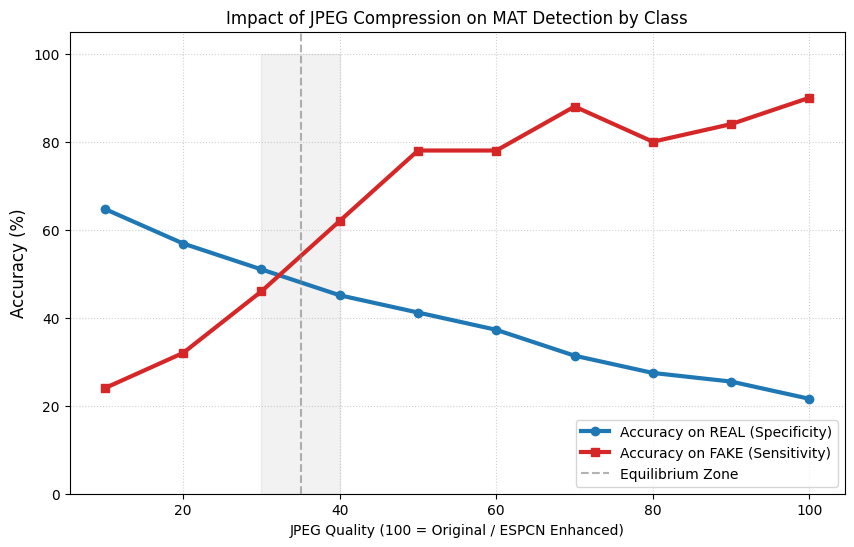

In [ ]:
import matplotlib.pyplot as plt

# obtained valus
qualities = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
acc_real = [64.71, 56.86, 50.98, 45.10, 41.18, 37.25, 31.37, 27.45, 25.49, 21.57]
acc_fake = [24.0, 32.0, 46.0, 62.0, 78.0, 78.0, 88.0, 80.0, 84.0, 90.0]

plt.figure(figsize=(10, 6))

plt.plot(qualities, acc_real, marker='o', linewidth=3, color='#1f77b4', label='Accuracy on REAL (Specificity)')
plt.plot(qualities, acc_fake, marker='s', linewidth=3, color='#d62728', label='Accuracy on FAKE (Sensitivity)')

plt.axvline(x=35, color='gray', linestyle='--', alpha=0.6, label='Equilibrium Zone')
plt.fill_between([30, 40], 0, 100, color='gray', alpha=0.1)

plt.title("Impact of JPEG Compression on MAT Detection by Class")
plt.xlabel("JPEG Quality (100 = Original / ESPCN Enhanced)")
plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(0, 105)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, loc='best')

plt.savefig("acc_real_vs_fake.png", dpi=300, bbox_inches='tight')
plt.show()

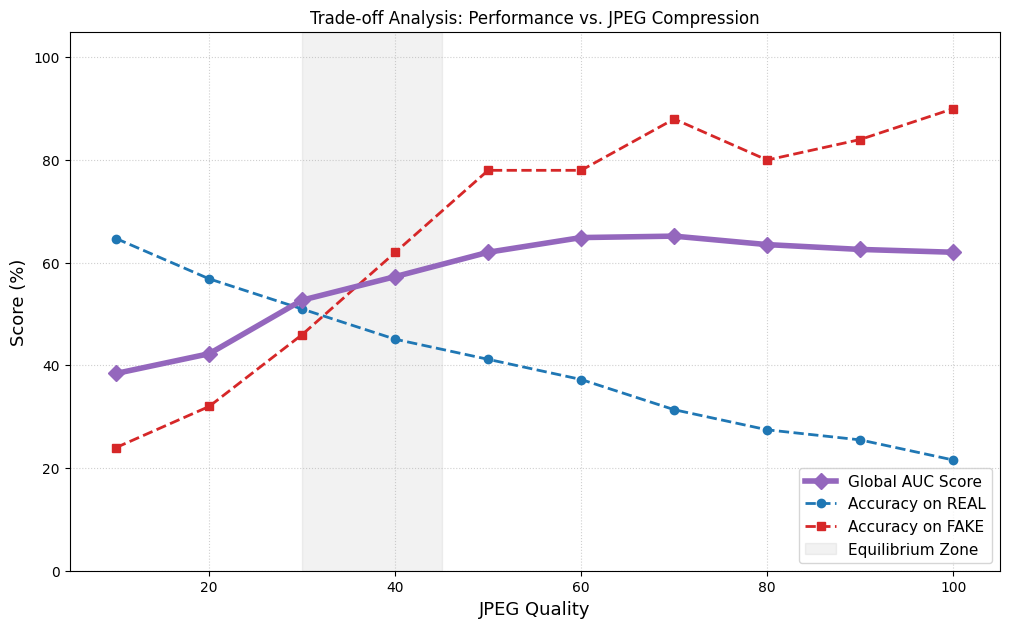

In [ ]:
qualities = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
auc_scores = [38.43, 42.27, 52.71, 57.29, 62.04, 64.90, 65.18, 63.53, 62.59, 62.04]
acc_real = [64.71, 56.86, 50.98, 45.10, 41.18, 37.25, 31.37, 27.45, 25.49, 21.57]
acc_fake = [24.0, 32.0, 46.0, 62.0, 78.0, 78.0, 88.0, 80.0, 84.0, 90.0]

plt.figure(figsize=(12, 7))

# auc
plt.plot(qualities, auc_scores, marker='D', markersize=8, linewidth=4,
         color='#9467bd', label='Global AUC Score', zorder=5)

# acc real
plt.plot(qualities, acc_real, marker='o', markersize=6, linewidth=2,
         color='#1f77b4', linestyle='--', label='Accuracy on REAL')

#acc fake
plt.plot(qualities, acc_fake, marker='s', markersize=6, linewidth=2,
         color='#d62728', linestyle='--', label='Accuracy on FAKE')

#intersection area
plt.axvspan(30, 45, color='gray', alpha=0.1, label='Equilibrium Zone')


plt.title("Trade-off Analysis: Performance vs. JPEG Compression")
plt.xlabel("JPEG Quality", fontsize=13)
plt.ylabel("Score (%)", fontsize=13)
plt.ylim(0, 105)
plt.xlim(5, 105)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True, fontsize=11)

#plt.savefig("unified_metrics_compression.png", dpi=300, bbox_inches='tight')
plt.show()

## Visualisation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2 # pour redimensionner les heatmaps proprement
from PIL import Image
import torch

attention_storage = {}

def get_attention_hook(name):
    def hook(model, input, output):
        attention_storage[name] = output.detach().cpu()
    return hook

def visualize_and_save(img_path, model, title_suffix=""):
    model.eval()

    original_img_pil = Image.open(img_path).convert('RGB').resize((380, 380))
    img_t = transform(original_img_pil).unsqueeze(0).to(device)

    handle = model.attentions.register_forward_hook(get_attention_hook('attentions'))

    #inference
    model(img_t)

    handle.remove()

    att_maps = attention_storage['attentions'].squeeze(0).numpy()

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f"Attentions vizualisation - {title_suffix}", fontsize=16, y=1.05)

    # Image 1 : originale
    axes[0].imshow(original_img_pil)
    axes[0].set_title("Input Image")
    axes[0].axis('off')

    # Images 2 à 5 : Les 4 têtes d'attention
    for i in range(4):
        heatmap = att_maps[i]

        heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-8)

        heatmap_resized = cv2.resize(heatmap, (380, 380), interpolation=cv2.INTER_LINEAR)

        # Affichage : Image originale + Heatmap transparente par dessus
        axes[i+1].imshow(original_img_pil)
        cax = axes[i+1].imshow(heatmap_resized, cmap='jet', alpha=0.5)
        axes[i+1].set_title(f"Attention Head {i+1}")
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

print("Outils de visualisation prêts !")

Outils de visualisation prêts !


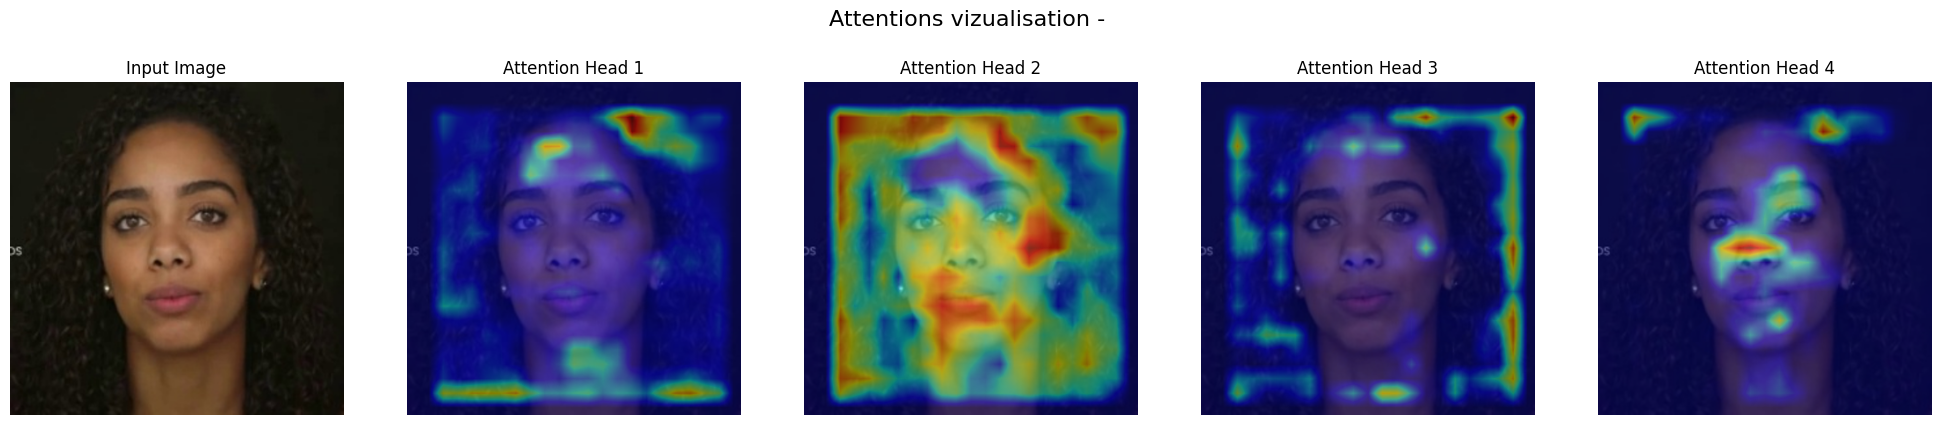

In [ ]:
# Remplace par le chemin d'UNE de tes images
test_image_path = f"{path}/datasets/real/00005_face_304.jpg" # <-- CHANGE ICI

# Génère le graphe Baseline
visualize_and_save(test_image_path, model)